# Домашняя работа №2
## Выполнил Тараканов Борис, ЗФИмд-01-25, ст.б. 1032259220

Для запуска кода нужно разместить в одной с кодом директорией папку data с данными, архивированную версию можно скачать тут: https://disk.yandex.ru/d/Q4s1e0htIzh72w

In [13]:
import os
import shutil
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms, models
from torchvision.io import decode_image, ImageReadMode
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from tqdm import tqdm
from pathlib import Path
from PIL import Image
import imagehash
from duckduckgo_search import DDGS
import warnings
warnings.filterwarnings('ignore')

In [14]:
seed = 42
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [15]:
CLASSES = ['honda', 'toyota', 'others']
NUM_CLASSES = len(CLASSES)

In [16]:
raw_data_root = Path("data/raw")
print("Raw image counts:")
for _cls in CLASSES:
    _folder = raw_data_root / _cls
    _count = len(list(_folder.glob('*.jpg'))) + len(list(_folder.glob('*.png')))
    print(f"{_cls}: {_count}")

Raw image counts:
honda: 1657
toyota: 1576
others: 1990


In [18]:
print("\nFinal image counts after cleaning:")
for cls in CLASSES:
    folder = raw_data_root / cls
    count = len(list(folder.glob('*.jpg'))) + len(list(folder.glob('*.png')))
    print(f"{cls}: {count}")


Final image counts after cleaning:
honda: 1657
toyota: 1576
others: 1990


In [19]:
train_root = Path("data/train")
val_root = Path("data/val")
for split in [train_root, val_root]:
    for _cls in CLASSES:
        (split / _cls).mkdir(parents=True, exist_ok=True)

# Copy files
for _cls in CLASSES:
    src_dir = raw_data_root / _cls
    images = list(src_dir.glob('*.jpg')) + list(src_dir.glob('*.png'))
    # Split
    train_imgs, val_imgs = train_test_split(images, test_size=0.2, random_state=42)
    for img in train_imgs:
        shutil.copy(img, train_root / _cls / img.name)
    for img in val_imgs:
        shutil.copy(img, val_root / _cls / img.name)
    print(f"{_cls}: train={len(train_imgs)}, val={len(val_imgs)}")

honda: train=1325, val=332
toyota: train=1260, val=316
others: train=1592, val=398


In [23]:
class CarDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = Path(root_dir)
        self.transform = transform
        self.classes = CLASSES
        self.class_to_idx = {cls: i for i, cls in enumerate(self.classes)}
        self.samples = []
        for cls in self.classes:
            cls_dir = self.root_dir / cls
            for img_path in cls_dir.glob('*.*'):
                if img_path.suffix.lower() in ['.jpg', '.jpeg', '.png']:
                    self.samples.append((str(img_path), self.class_to_idx[cls]))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, label

train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1)),
    transforms.ColorJitter(brightness=0.25, contrast=0.25, saturation=0.25, hue=0.1),
    transforms.RandomPerspective(distortion_scale=0.2, p=0.3),
    transforms.GaussianBlur(kernel_size=(3, 3), sigma=(0.1, 1.5)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_dataset = CarDataset(train_root, transform=train_transforms)
val_dataset = CarDataset(val_root, transform=val_transforms)

print(f"Train size: {len(train_dataset)}, Val size: {len(val_dataset)}")

batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)
print(f"Batches: train={len(train_loader)}, val={len(val_loader)}")

Train size: 4177, Val size: 1046
Batches: train=66, val=17


In [24]:
batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)
print(f"Batches: train={len(train_loader)}, val={len(val_loader)}")

Batches: train=66, val=17


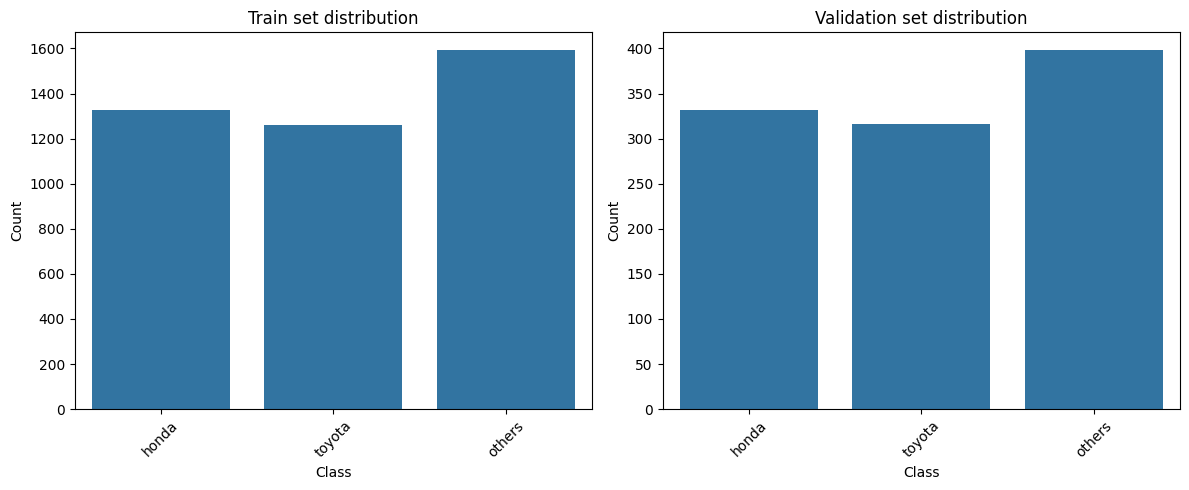

In [25]:
train_counts = [0]*len(CLASSES)
for _, label in train_dataset:
    train_counts[label] += 1
val_counts = [0]*len(CLASSES)
for _, label in val_dataset:
    val_counts[label] += 1

fig, axes = plt.subplots(1,2, figsize=(12,5))
sns.barplot(x=CLASSES, y=train_counts, ax=axes[0])
axes[0].set_title('Train set distribution')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

sns.barplot(x=CLASSES, y=val_counts, ax=axes[1])
axes[1].set_title('Validation set distribution')
axes[1].set_xlabel('Class')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

In [26]:
class ResNetForFineTune(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES, dropout_rate=0.5):
        super().__init__()
        self.resnet = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
        in_features = self.resnet.fc.in_features
        self.resnet.fc = nn.Sequential(
            nn.Dropout(p=dropout_rate),
            nn.Linear(in_features, num_classes)
        )

    def forward(self, x):
        return self.resnet(x)

model = ResNetForFineTune(dropout_rate=0.5)
model.to(device)

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)

In [27]:
def train(model, loss_fn, optimizer, dataloader, device):
    model.train()
    train_loss = 0
    train_acc = 0
    it_count = len(dataloader)
    pbar = tqdm(total=it_count, desc="Training")
    for batch, (images, labels) in enumerate(dataloader):
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = loss_fn(outputs, labels)
        train_loss += loss.item()
        train_acc += (outputs.argmax(dim=1) == labels).float().mean().item()
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        pbar.update(1)
        if batch % max(1, it_count//3) == 0:
            pbar.set_description(f"Train_loss: {train_loss/(batch+1):.3f} Train_acc: {train_acc/(batch+1):.3f}")
    pbar.close()
    return train_loss/it_count, train_acc/it_count

def test(model, loss_fn, dataloader, device):
    model.eval()
    test_loss = 0
    test_acc = 0
    it_count = len(dataloader)
    pbar = tqdm(total=it_count, desc="Validation")
    with torch.no_grad():
        for batch, (images, labels) in enumerate(dataloader):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = loss_fn(outputs, labels)
            test_loss += loss.item()
            test_acc += (outputs.argmax(dim=1) == labels).float().mean().item()
            pbar.update(1)
            if batch % max(1, it_count//3) == 0:
                pbar.set_description(f"Val_loss: {test_loss/(batch+1):.3f} Val_acc: {test_acc/(batch+1):.3f}")
    pbar.close()
    return test_loss/it_count, test_acc/it_count

def train_loop(model, loss_fn, optimizer, train_loader, val_loader, device, num_epochs=30, patience=7):
    train_losses, val_losses = [], []
    train_accs, val_accs = [], []
    best_val_acc = 0
    epochs_no_improve = 0
    best_epoch = 0

    for epoch in range(num_epochs):
        print(f"\nEPOCH {epoch+1}/{num_epochs}" + "-"*50)
        train_loss, train_acc = train(model, loss_fn, optimizer, train_loader, device)
        val_loss, val_acc = test(model, loss_fn, val_loader, device)

        train_losses.append(train_loss)
        train_accs.append(train_acc)
        val_losses.append(val_loss)
        val_accs.append(val_acc)

        # Early stopping logic
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_epoch = epoch + 1
            torch.save(model.state_dict(), 'best_model.pth')
            print(f"Saved best model! (Val Acc: {best_val_acc:.4f})")
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            print(f"No improvement for {epochs_no_improve} epoch(s).")

        if epochs_no_improve >= patience:
            print(f"\nEarly stopping triggered after {epoch+1} epochs. Best val acc: {best_val_acc:.4f} at epoch {best_epoch}")
            break

    print(f"\nTraining finished. Best validation accuracy: {best_val_acc:.4f}")
    return train_losses, val_losses, train_accs, val_accs

In [28]:
for batch_idx, (images, labels) in enumerate(train_loader):
    print(f"Batch {batch_idx}: images shape {images.shape}, labels {labels.shape}")
    if batch_idx == 2:
        break

Batch 0: images shape torch.Size([64, 3, 224, 224]), labels torch.Size([64])
Batch 1: images shape torch.Size([64, 3, 224, 224]), labels torch.Size([64])
Batch 2: images shape torch.Size([64, 3, 224, 224]), labels torch.Size([64])


In [29]:
num_epochs = 30
history = train_loop(model, criterion, optimizer, train_loader, val_loader, device, num_epochs)
train_losses, val_losses, train_accs, val_accs = history


EPOCH 1/30--------------------------------------------------


Val_loss: 0.900 Val_acc: 0.606: 100%|██████████████████████████████████████████████████| 17/17 [00:06<00:00,  2.64it/s]


Saved best model! (Val Acc: 0.6029)

EPOCH 2/30--------------------------------------------------


Val_loss: 0.834 Val_acc: 0.692: 100%|██████████████████████████████████████████████████| 17/17 [00:06<00:00,  2.72it/s]


Saved best model! (Val Acc: 0.6971)

EPOCH 3/30--------------------------------------------------


...

Saved best model! (Val Acc: 0.8278)

EPOCH 29/30--------------------------------------------------


Val_loss: 0.631 Val_acc: 0.819: 100%|██████████████████████████████████████████████████| 17/17 [00:07<00:00,  2.40it/s]


No improvement for 1 epoch(s).

EPOCH 30/30--------------------------------------------------


Val_loss: 0.631 Val_acc: 0.826: 100%|██████████████████████████████████████████████████| 17/17 [00:07<00:00,  2.41it/s]

No improvement for 2 epoch(s).

Training finished. Best validation accuracy: 0.8278


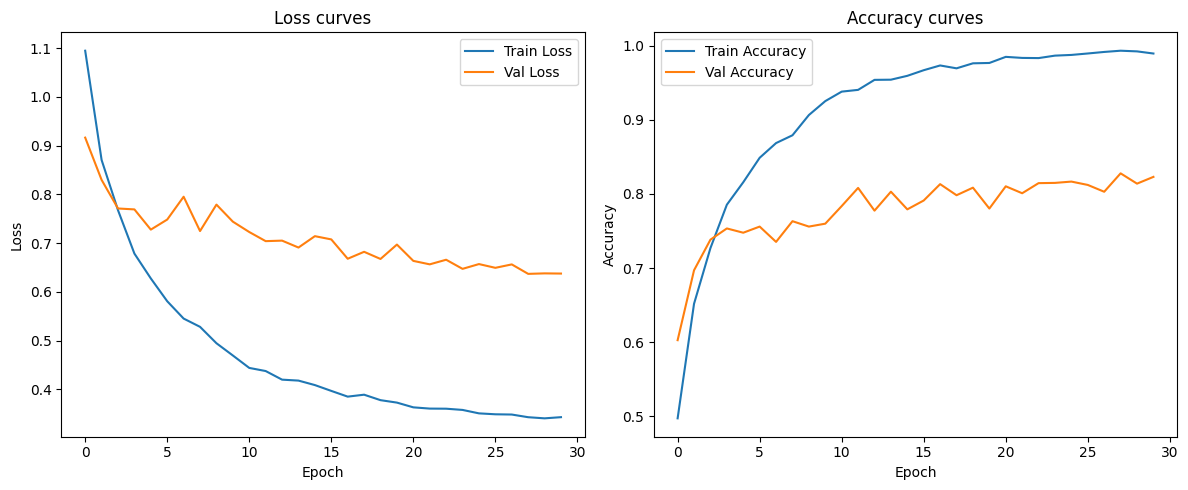

In [36]:
# Plot training curves
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss curves')

plt.subplot(1,2,2)
plt.plot(train_accs, label='Train Accuracy')
plt.plot(val_accs, label='Val Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy curves')
plt.tight_layout()
plt.show()

Validation Set Evaluation:
              precision    recall  f1-score   support

       honda       0.89      0.77      0.82       332
      toyota       0.81      0.83      0.82       316
      others       0.82      0.90      0.86       398

    accuracy                           0.83      1046
   macro avg       0.84      0.83      0.83      1046
weighted avg       0.84      0.83      0.83      1046

Accuracy: 0.8337


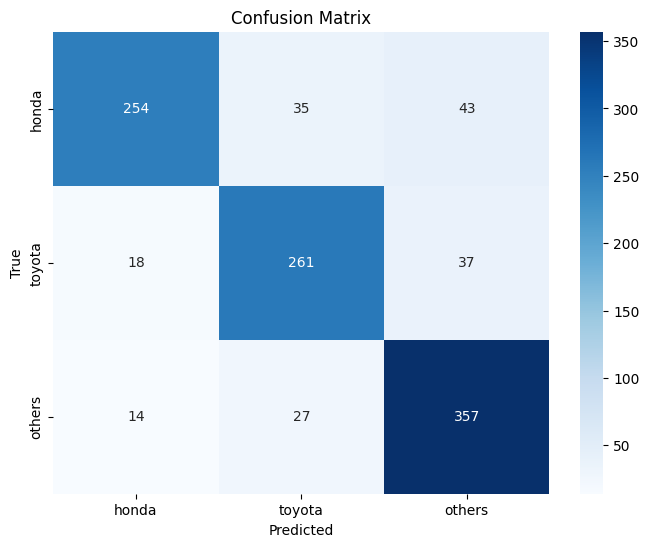

In [37]:
def evaluate_model(model, dataloader, device):
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(predicted.cpu().numpy())
    cm = confusion_matrix(y_true, y_pred)
    report = classification_report(y_true, y_pred, target_names=CLASSES)
    acc = np.sum(np.diag(cm)) / np.sum(cm)
    return cm, report, acc

def plot_confusion_matrix(cm, classes):
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.show()

model.load_state_dict(torch.load('best_model.pth', map_location=device))
cm, report, acc = evaluate_model(model, val_loader, device)
print("Validation Set Evaluation:")
print(report)
print(f"Accuracy: {acc:.4f}")
plot_confusion_matrix(cm, CLASSES)

In [38]:
custom_test_root = Path("data/custom_test")
if not custom_test_root.exists():
    custom_test_root.mkdir(parents=True)
    for cls in CLASSES:
        (custom_test_root / cls).mkdir(exist_ok=True)
    print("Created custom_test folder. Please add your own photos into the class subfolders.")

In [43]:
custom_val_transforms = transforms.Compose([
    transforms.Lambda(lambda img: img.rotate(-90, expand=True)), 
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

if custom_test_root.exists() and any((custom_test_root / cls).iterdir() for cls in CLASSES):
    custom_dataset = CarDataset(custom_test_root, transform=custom_val_transforms)
    custom_loader = DataLoader(custom_dataset, batch_size=32, shuffle=False)
    print(f"Custom test set size: {len(custom_dataset)}")
    cm_custom, report_custom, acc_custom = evaluate_model(model, custom_loader, device)
    print("\nCustom Test Set Evaluation (own photos with forced rotation):")
    print(report_custom)
    print(f"Accuracy: {acc_custom:.4f}")
else:
    print("No custom test images found. Please add your photos to data/custom_test/class/")

Custom test set size: 70

Custom Test Set Evaluation (own photos with forced rotation):
              precision    recall  f1-score   support

       honda       0.47      0.81      0.59        26
      toyota       0.39      0.64      0.48        11
      others       0.71      0.15      0.25        33

    accuracy                           0.47        70
   macro avg       0.52      0.53      0.44        70
weighted avg       0.57      0.47      0.41        70

Accuracy: 0.4714


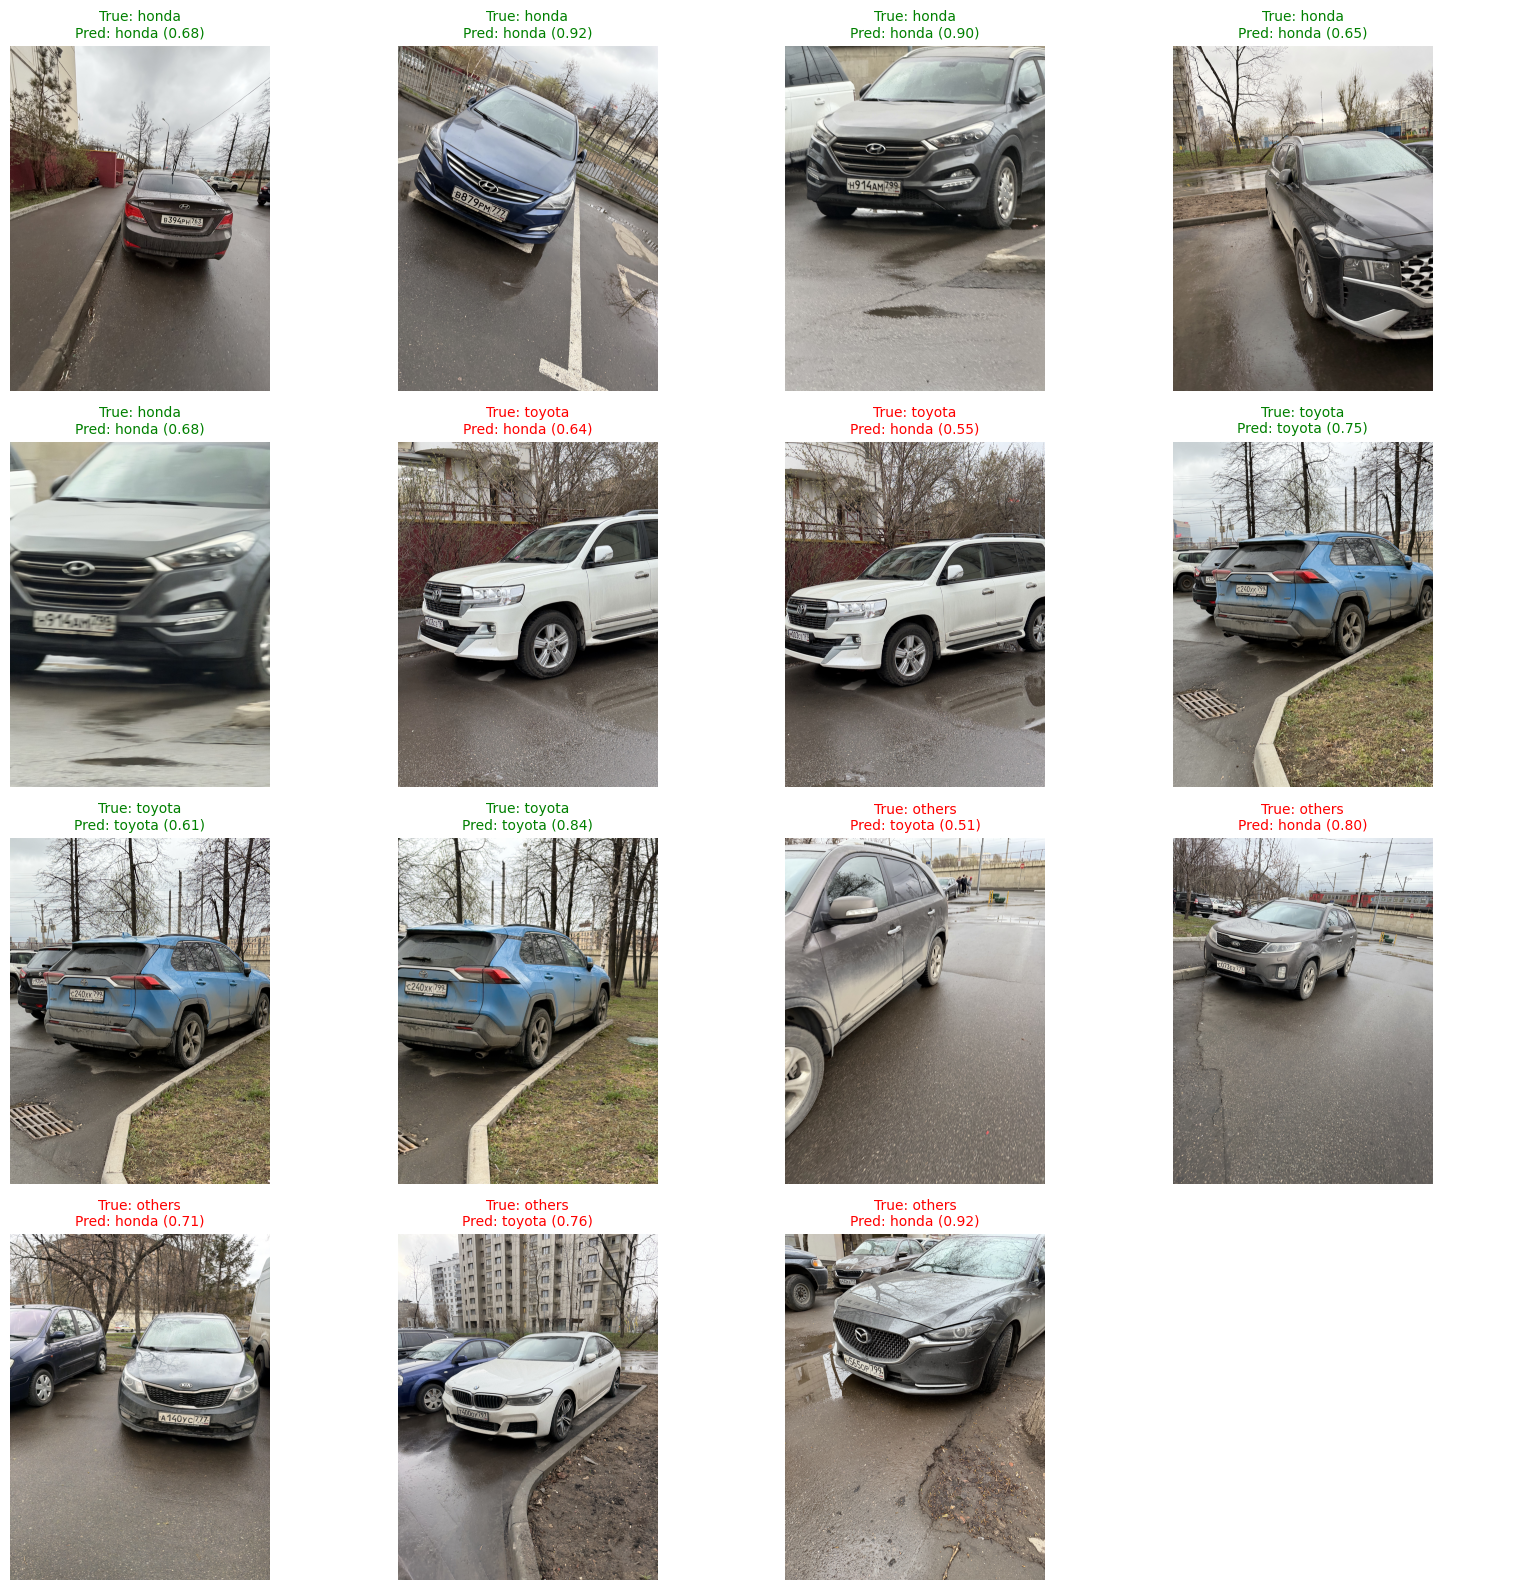

In [50]:
FORCED_ROTATION_ANGLE = -90  

def predict_image(model, image_path, device):
    image = Image.open(image_path).convert('RGB')
    
    if FORCED_ROTATION_ANGLE != 0:
        image = image.rotate(FORCED_ROTATION_ANGLE, expand=True)
    
    original = image.copy()  
    
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    input_tensor = transform(image).unsqueeze(0).to(device)
    
    with torch.no_grad():
        outputs = model(input_tensor)
        probabilities = torch.nn.functional.softmax(outputs[0], dim=0).cpu().numpy()
        pred_idx = probabilities.argmax()
        pred_class = CLASSES[pred_idx]
        confidence = probabilities[pred_idx]
    return original, pred_class, confidence, probabilities

n_images_per_class = 5  
max_total = 16          

all_images = []
for class_name in CLASSES:
    class_dir = custom_test_root / class_name
    if not class_dir.exists():
        continue
    images = list(class_dir.glob('*.*'))
    images = [p for p in images if p.suffix.lower() in ['.jpg', '.jpeg', '.png']]
    random.shuffle(images)
    selected = images[:n_images_per_class]
    for img_path in selected:
        all_images.append((img_path, class_name))

if len(all_images) > max_total:
    all_images = all_images[:max_total]

if not all_images:
    print("Нет изображений в data/custom_test.")
else:
    n_cols = 4
    n_rows = (len(all_images) + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4*n_rows))
    axes = axes.flatten() if n_rows > 1 else [axes]

    for idx, (img_path, true_class) in enumerate(all_images):
        original, pred_class, confidence, probs = predict_image(
            model, img_path, device
        )
        axes[idx].imshow(original)
        axes[idx].axis('off')
        color = 'green' if pred_class == true_class else 'red'
        axes[idx].set_title(
            f"True: {true_class}\nPred: {pred_class} ({confidence:.2f})",
            color=color,
            fontsize=10
        )
    for idx in range(len(all_images), len(axes)):
        axes[idx].axis('off')
    plt.tight_layout()
    plt.show()